### Email Spam Detection

In [9]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
# Dataset
X = np.array([[0,120],[1,150],[0,90],[2,130],[5,40],[6,60],[7,55],[4,70]])
y = np.array([0,0,0,0,1,1,1,1])

In [11]:
def predict(x,w,b):
    score = w[0]*x[0]+w[1]*x[1]+b

    if score>0:
        return 1
    
    else:
        return 0

In [12]:
def compute(X,y,w,b):
    correct = 0
    for i in range(len(X)):
        pred = predict(X[i],w,b)

        if pred == y[i]:
            correct+=1
    
    return correct/len(X)

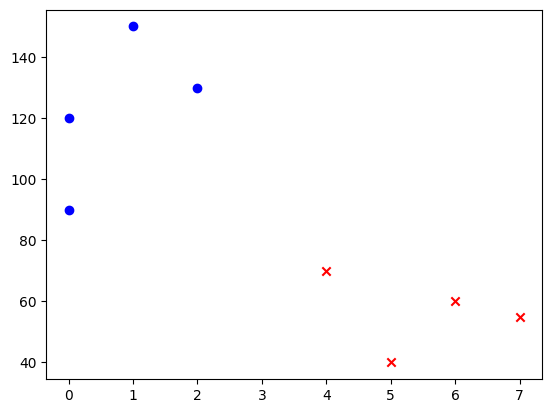

In [13]:
# Plotting to check points

for i in range(len(X)):
    if y[i]==0:
        plt.scatter(X[i][0],X[i][1], marker='o', color="blue", label="Not Spam" if y[i]==0 else "")
    
    else:
        plt.scatter(X[i][0],X[i][1], marker='x', color="red", label="Spam" if y[i]==4 else "")


In [14]:
# Random search
best_acc = 0
best_w = None
best_b = None

for _ in range(1000):
    w = [random.uniform(-10,10), random.uniform(-10,10)]
    b = random.uniform(-10,10)

    acc = compute(X,y,w,b)

    if acc>best_acc:
        best_acc = acc
        best_w = w
        best_b = b

print("Accuracy: ", acc)
print("Best Weight: ",best_w)
print("Best Bias: ",best_b)

Accuracy:  0.5
Best Weight:  [5.5361769515529335, -0.24924273151342646]
Best Bias:  6.972729360658761


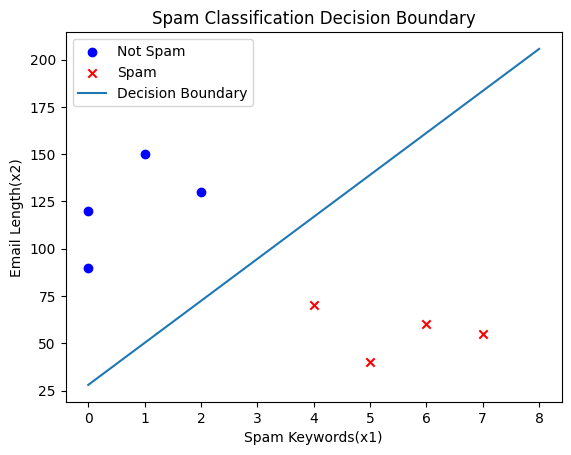

In [15]:
for i in range(len(X)):
    if y[i]==0:
        plt.scatter(X[i][0],X[i][1], marker='o', color="blue", label="Not Spam" if i==0 else "")
    
    else:
        plt.scatter(X[i][0],X[i][1], marker='x', color="red", label="Spam" if i==4 else "")

w1,w2 = best_w
b = best_b

x_vals = np.linspace(0, 8, 100)

# Plot decision boundary
if w2!=0:
    y_vals = -(w1/w2)*x_vals -(b/w2)
    plt.plot(x_vals,y_vals, label="Decision Boundary")

else:
    x_line = -b/w1
    plt.axvline(x=x_line, label="Decision Boundary")

# Labels
plt.xlabel("Spam Keywords(x1)")
plt.ylabel("Email Length(x2)")
plt.title("Spam Classification Decision Boundary")
plt.legend()
plt.show()